<a href="https://colab.research.google.com/github/Zafir-Akhter/Plant-disease-using-CNN/blob/main/E11420240_Final_Project_Vision_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Final Project:  Vision Transformers

- Student Name: Zafir Akhter / ID: E11420240 / Class: IPCS2A (your name and ID here)
- Submission date: 2026/6/1
- Program: https://t.ly/sFRCe (re: [short url](https://chrome.google.com/webstore/detail/url-shortener/oodfdmglhbbkkcngodjjagblikmoegpa))
- This program is produced by
![yll](https://drive.google.com/uc?export=view&id=1HXGUvSIOoAO46EYVa_PGl2Gn5orvZ6Wc)
![qrcode](https://api.qrserver.com/v1/create-qr-code/?data=https://t.ly/sFRCe&size=100x100)



## **Submission guidlines:**
1. Copy this colab sample to your own google drive, the suggested file name is: [your-std-id].ipynb
1. Please change the data (date/your photo/QR-code) in the content of the first cell and set the student name to your name.
1. !!! Remember to right-click your ipynb file, click "**Share**", and change the permission to: **"Share with people who know the link"**, so that the teacher can test your homework. !!!
1. Use Runtime -> Run all (ctl-F9), use File -> Print (ctl-P) after one execution to generate a PDF file and rename it to [your-id].PDF (eg s01234567.pdf)
1. !!! **Please submit the PDF file when handing in the homework**. !!!


# Vision Transformers

In this notebook, we will define and implement the Vision Transformer model.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import numpy as np

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

## Vision Transformer

<img src='https://drive.google.com/uc?id=1_VQOC4V6iFF_NMKC-g2UmBFkQOwm4TJ-' />

>Inspired by the Transformer scaling successes in NLP, we experiment with applying a standard Transformer directly to images, with the fewest possible modifications. To do so, **we split an image into patches and provide the sequence of linear embeddings of these patches as an input to a Transformer**. Image patches are treated the same way as tokens (words) in an NLP application. We train the model on image classification in supervised fashion.  <br><sub>1 Introduction<sub>

>In model design we follow the original Transformer (Vaswani et al., 2017) as closely as possible.
An advantage of this intentionally simple setup is that scalable NLP Transformer architectures – and
their efficient implementations – can be used almost out of the box. <br><sub>3 Method<sub>


## Model Configuration

<img src='https://drive.google.com/uc?id=1IB2-I_zGLm5VmCKTdAfc0SXPaxEcV_A1' />



We will walk through the components of Vision Transformer:
>- Image Patches
-Embedding Patches
-[Class] Token
-Positional Information
-Self-Attention
-Multi-Head Self-Attention
-Multi-Layer Perceptron
-Transformer Encoder
-Classification Head
-Vision Transformer

## Image To Patches
<img src='https://drive.google.com/uc?id=1HnemkTTAyd0_5mTXXhFAIugaykiUw3Ea' />

In [ ]:
# unit test on patching an image

import urllib.request

urllib.request.urlretrieve(
  'https://drive.google.com/uc?id=1h6ODFoGIMLgLGOiTdWz7CKWdJPOjUiu8',
   "car.png")

# read image and resize to 128
image = Image.open('car.png').resize((128, 128))

# convert to numpy array
x = np.array(image)


# An Image Is Worth 16x16 Words
P = 16   # patch size
C = 3    # number of channels (RGB)

# split image into patches using numpy
patches = x.reshape(x.shape[0]//P, P, x.shape[1]//P, P, C).swapaxes(1, 2).reshape(-1, P, P, C)

# flatten patches
x_p = np.reshape(patches, (-1, P * P * C))

# get number of patches
N = x_p.shape[0]

print('Image shape: ', x.shape)  # width, height, channel
print('Number of patches: {} with resolution ({}, {})'.format(N, P, P))
print('Patches shape: ', patches.shape)
print('Flattened patches shape: ', x_p.shape)

Image shape:  (128, 128, 3)
Number of patches: 64 with resolution (16, 16)
Patches shape:  (64, 16, 16, 3)
Flattened patches shape:  (64, 768)


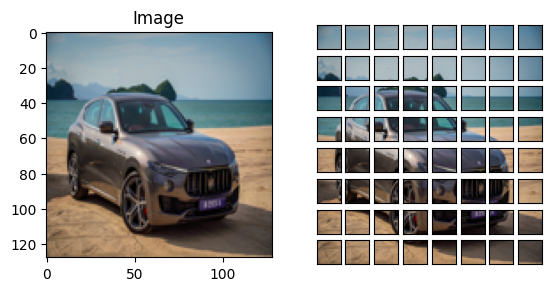

In [ ]:
# visualize data
#
# display image and patches side-by-side

fig = plt.figure()

gridspec = fig.add_gridspec(1, 2)
ax1 = fig.add_subplot(gridspec[0])
ax1.set(title='Image')

# display image
ax1.imshow(x)

subgridspec = gridspec[1].subgridspec(8, 8, hspace=-0.8)

# display patches
for i in range(8):    # N = 64, 8x8 grid
    for j in range(8):
        num = i * 8 + j
        ax = fig.add_subplot(subgridspec[i, j])
        ax.set(xticks=[], yticks=[])
        ax.imshow(patches[num])

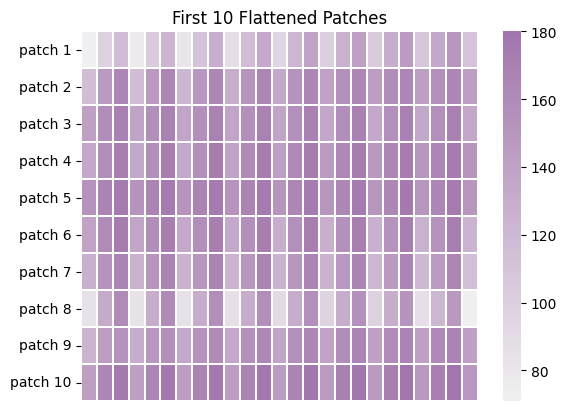

In [ ]:
# visualize data
#
# display flattened patches

# display first 10 flattened patches up to 25 values
heat_map = x_p[:10, :25]

yticklabels = ['patch ' + str(i + 1) for i in range(10)]

plt.title('First 10 Flattened Patches')
ax = sns.heatmap(heat_map,
                 cmap=sns.light_palette("#a275ac", as_cmap=True),
                 xticklabels=False, yticklabels=yticklabels,
                 linewidths=0.01, linecolor='white'
                )


## Embedding Patches

<img src='https://drive.google.com/uc?id=1otAErIvmK1LjzBb8AWT-lh7bvVwg7cEi' width=80% height=80% />

>The Transformer uses constant latent vector size D through all of its layers, so we flatten the patches and map to D dimensions with a trainable linear projection. We refer to the output of this projection as the **patch embeddings**. <br><sub>3.1 Vision Transformer (ViT)<sub>

In [ ]:
# unit test on patch embeddings

# dimensionality of patch embeddings
D = 768

# batch size
B = 1

# convert flattened patches to tensor
x_p = torch.Tensor(x_p)

# add batch dimension
x_p = x_p[None, ...]

# weight matrix E
E = nn.Parameter(torch.randn(1, P * P * C, D))

patch_embeddings = torch.matmul(x_p , E)

assert patch_embeddings.shape == (B, N, D)
print(patch_embeddings.shape)

torch.Size([1, 64, 768])


## Class Token

<img src='https://drive.google.com/uc?id=1-Z4jAPogjk8cAkzMwKNereXQ8qZHUjKO' width=55% height=55%/>

>In order to perform classification, we use the standard approach of adding an extra learnable “classification token” to the sequence. <br><sub>Model Overview<sub>

>Similar to BERT’s [class] token, we prepend a learnable embedding to the sequence of embedded patches (xclass). <br><sub>3.1 Vision Transformer (ViT)<sub>

In [ ]:
# unit test on class token

# init class token
class_token = nn.Parameter(torch.randn(1, 1, D))

patch_embeddings = torch.cat((class_token, patch_embeddings), 1)

print(patch_embeddings.shape)
assert patch_embeddings.shape == (B, N + 1, D)

torch.Size([1, 65, 768])


## Position Embedding
<img src='https://drive.google.com/uc?id=1EprjkndxJk0frqLkeeDMhHuX-BqPQTg2' width=60% height=60%/>

>Position embeddings are added to the patch embeddings to **retain positional information**. We use
standard learnable 1D position embeddings. <br><sub>3.1 Vision Transformer (ViT)<sub>

In [ ]:
# unit test on position embedddings

# position embeddings
E_pos = nn.Parameter(torch.randn(1, N + 1, D))

z0 = patch_embeddings + E_pos

print(z0.shape)
assert z0.shape == (B, N + 1, D)

torch.Size([1, 65, 768])


## Self-Attention

<img src='https://drive.google.com/uc?id=1hVG_BB_oW5f8ZNP3vOAYlK7npzbHDtb4'/>

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embedding_dim=768, key_dim=64):
        super(SelfAttention, self).__init__()

        self.embedding_dim = embedding_dim   # D -> embedding dimensionaltiy
        self.key_dim = key_dim               # D_h -> key, query, value dimensionality

        # U_kqv weight matrix
        self.W = nn.Parameter(torch.randn(embedding_dim, 3*key_dim))

    def forward(self, x):
        key_dim = self.key_dim

        # get query, key and value projection
        qkv = torch.matmul(x, self.W)

        # get query, key, value
        q = qkv[:, :, :key_dim]
        k = qkv[:, :, key_dim:key_dim*2 ]
        v = qkv[:, :, key_dim*2:]

        # compute dot product of the all query with all keys
        k_T = torch.transpose(k, -2, -1)   # get transpose of key
        dot_products = torch.matmul(q, k_T)

        # divide each by √Dh
        scaled_dot_products = dot_products / np.sqrt(key_dim)

        # apply a softmax function to obtain attention weights -> A
        attention_weights = F.softmax(scaled_dot_products, dim=1)

        # get weighted values
        weighted_values = torch.matmul(attention_weights, v)

        # return weighted_values
        return weighted_values

In [ ]:
# unit test on self-attention

# dimensionality of key, query and value
D_h = 64

# init self-attention
self_attention = SelfAttention(D, D_h)   # embedding_dim, key_dim

attention_scores = self_attention(patch_embeddings)

print(attention_scores.shape)
assert attention_scores.shape == (B, N + 1, D_h)

torch.Size([1, 65, 64])


## Multi-Head Self-Attention

<img src='https://drive.google.com/uc?id=1BwamFmKIg72nrTBeLJr8otvF6B2WDpUn'/>

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dim=768, num_heads=12):
        super(MultiHeadSelfAttention, self).__init__()

        self.num_heads = num_heads            # set number of heads (k)
        self.embedding_dim = embedding_dim    # set dimensionality

        assert embedding_dim % num_heads == 0   # dimensionality should be divisible by number of heads
        self.key_dim = embedding_dim // n_head   # set key,query and value dimensionality

        # init self-attentions
        self.attention_list = [SelfAttention(embedding_dim, self.key_dim) for _ in range(num_heads)]
        self.multi_head_attention = nn.ModuleList(self.attention_list)

        # init U_msa weight matrix
        self.W = nn.Parameter(torch.randn(num_heads * self.key_dim, embedding_dim))

    def forward(self, x):
        # compute self-attention scores of each head
        attention_scores = [attention(x) for attention in self.multi_head_attention]

        # concat attentions
        Z = torch.cat(attention_scores, -1)

        # compute multi-head attention score
        attention_score = torch.matmul(Z, self.W)

        return attention_score


In [ ]:
# unit test on multi-head self-attention

# number of heads (k)
n_head = 12

# init multi-head self-attention
multi_head_attention = MultiHeadSelfAttention(D, n_head)

# compute MSA score
attention_score = multi_head_attention(patch_embeddings)

print(attention_score.shape)
assert attention_score.shape == (B, N + 1, D)

torch.Size([1, 65, 768])


## Multi-Layer Perceptron

<img src='https://drive.google.com/uc?id=10ITRufcZRm_4xrXp4_zhdhShzBYQTRsp' width=80% height=80%/>

>The MLP contains two layers with a GELU non-linearity. <br><sub>3.1 Vision Transformer (ViT)<sub>

In [ ]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim=3072):
        super(MultiLayerPerceptron, self).__init__()

        self.mlp = nn.Sequential(
                            nn.Linear(embedding_dim, hidden_dim),
                            nn.GELU(),
                            nn.Linear(hidden_dim, embedding_dim)
                   )

    def forward(self, x):
        # pass through multi-layer perceptron
        x = self.mlp(x)
        return x

In [ ]:
# unit test on multi-layer perceptron

# hidden layer dimensionality
hidden_dim = 3072

# init mlp
mlp = MultiLayerPerceptron(D, hidden_dim)

# compute mlp output
output = mlp(patch_embeddings)

assert output.shape == (B, N + 1, D)
output.shape

torch.Size([1, 65, 768])

## Transformer Encoder

<img src='https://drive.google.com/uc?id=1msdVyorMThi1vn4exbC9_XfxIsqnJQnc'/>

>The Transformer encoder consists of alternating layers of multiheaded self-attention (MSA) and MLP blocks. Layernorm (LN) is applied before every block, and residual connections after every block. <br><sub>3.1 Vision Transformer (ViT)<sub>

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim=768, num_heads=12, hidden_dim=3072, dropout_prob=0.1):
        super(TransformerEncoder, self).__init__()

        self.MSA = MultiHeadSelfAttention(embedding_dim, num_heads)
        self.MLP = MultiLayerPerceptron(embedding_dim, hidden_dim)

        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.layer_norm2 = nn.LayerNorm(embedding_dim)

        self.dropout1 = nn.Dropout(p=dropout_prob)
        self.dropout2 = nn.Dropout(p=dropout_prob)
        self.dropout3 = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        # apply dropout
        out_1 = self.dropout1(x)
        # apply layer normalization
        out_2 = self.layer_norm1(out_1)
        # compute multi-head self-attention
        msa_out = self.MSA(out_2)
        # apply dropout
        out_3 = self.dropout2(msa_out)
        # apply residual connection
        res_out = x + out_3
        # apply layer normalization
        out_4 = self.layer_norm2(res_out)
        # compute mlp output
        mlp_out = self.MLP(out_4)
        # apply dropout
        out_5 = self.dropout3(mlp_out)
        # apply residual connection
        output = res_out + out_5

        return output

In [ ]:
# unit test on transformer encoder

# dropout probability
dropout_prob = 0.1

# init transformer encoder
transformer_encoder = TransformerEncoder(D, n_head, hidden_dim, dropout_prob)

# compute transformer encoder output
output = transformer_encoder(patch_embeddings)

assert output.shape == (B, N + 1, D)
output.shape

torch.Size([1, 65, 768])

<img src='https://drive.google.com/uc?id=1Qij2VIIIj_Md4hAQLGIwOkUpxMQ2SNTS' width=60% height=60%/>

>We found strong regularization to be key when training models from scratch on ImageNet. Dropout, when used, is applied after every dense layer except for the the qkv-projections and directly after adding positional to patch embeddings. <br><sub>B.1 Training<sub>

## MLP Head

<img src='https://drive.google.com/uc?id=1FZL9w-Wzy5YYW6iu6eFe54GJYHjxpKM9'/>

>The classification head is implemented by a MLP with one hidden layer at pre-training
time and by a single linear layer at fine-tuning time. <br><sub>3.1 Vision Transformer (ViT)<sub>

> In order to stay as close as possible to the original Transformer model, we made use of an additional [class] token, which is taken as image representation. The output of this token is then transformed into a class prediction via a small multi-layer perceptron (MLP) with tanh as non-linearity in the single hidden layer. <br><sub>D.3 Head Type and Class Token<sub>

In [ ]:
class MLPHead(nn.Module):
    def __init__(self, embedding_dim=768, num_classes=10, fine_tune=False):
        super(MLPHead, self).__init__()
        self.num_classes = num_classes

        if not fine_tune:
            # hidden layer with tanh activation function
            self.mlp_head = nn.Sequential(
                                    nn.Linear(embedding_dim, 3072),  # hidden layer
                                    nn.Tanh(),
                                    nn.Linear(3072, num_classes)    # output layer
                            )
        else:
            # single linear layer
            self.mlp_head = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = self.mlp_head(x)
        return x


In [ ]:
# unit test on classification head


# extract [class] token from transformer encoder output
z_L = output[0][0]   # extract batch and [class] token

# init number of classes
n_class = 10

# init classification head for pre-training phase
mlp_head_pretrain = MLPHead(D, n_class)
# init classification head for fine-tuning phase
mlp_head_finetune = MLPHead(D, n_class, fine_tune=True)

# compute mlp head output
output_1 = mlp_head_pretrain(z_L)
# compute mlp head output for fine-tuning
output_2 = mlp_head_finetune(z_L)

# size of output
print(output_1.size(dim=0))

# assert output is consistent with number of classes
assert output_1.size(dim=0) == n_class
assert output_2.size(dim=0) == n_class

10


## Vision Transformer

<img src='https://drive.google.com/uc?id=1Q8vD7f-c0N8izFagyXngm3Gy2tlU3LVE'/>

>We split an image into fixed-size patches, linearly embed each of them, add position embeddings, and feed the resulting sequence of vectors to a standard Transformer encoder. <br><sub>Model Overview<sub>

<img src='https://drive.google.com/uc?id=118AfS8AtvrHWGrz8pD8bCzh7QqPL5K8G'/>

> The output of the Transformer encoder (zL0) serves as the image representation y. Both during pre-training and fine-tuning, a classification head is attached to zL0. <br><sub>3.1 Vision Transformer (ViT)<sub>


In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, patch_size=16, image_size=224, channel_size=3,
                     num_layers=12, embedding_dim=768, num_heads=12, hidden_dim=3072,
                            dropout_prob=0.1, num_classes=10, pretrain=True):
        super(VisionTransformer, self).__init__()

        self.patch_size = patch_size
        self.channel_size = channel_size
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.dropout_prob = dropout_prob
        self.num_classes = num_classes

        # get number of patches of the image
        self.num_patches = int(image_size ** 2 / patch_size ** 2)   # height * width / patch size ^ 2

        # trainable linear projection for mapping dimension of patches (weight matrix E)
        self.W = nn.Parameter(
                    torch.randn( patch_size * patch_size * channel_size, embedding_dim))

        # position embeddings (E_pos)
        self.pos_embedding = nn.Parameter(torch.randn(self.num_patches + 1, embedding_dim))

        # learnable class token embedding (x_class)
        self.class_token = nn.Parameter(torch.rand(1, D))

        # stack transformer encoder layers
        transformer_encoder_list = [
            TransformerEncoder(embedding_dim, num_heads, hidden_dim, dropout_prob)
                    for _ in range(num_layers)]
        self.transformer_encoder_layers = nn.Sequential(*transformer_encoder_list)

        # mlp head
        self.mlp_head = MLPHead(embedding_dim, num_classes)

    def forward(self, x):
        # get patch size and channel size
        P, C = self.patch_size, self.channel_size

        # split image into patches
        patches = x.unfold(1, C, C).unfold(2, P, P).unfold(3, P, P)
        patches = patches.contiguous().view(patches.size(0), -1, C * P * P).float()

        # linearly embed patches
        patch_embeddings = torch.matmul(patches , self.W)

        # add class token
        batch_size = patch_embeddings.shape[0]
        patch_embeddings = torch.cat((self.class_token.repeat(batch_size, 1, 1), patch_embeddings), 1)

        # add positional embedding
        patch_embeddings = patch_embeddings + self.pos_embedding

        # feed patch embeddings into a stack of Transformer encoders
        transformer_encoder_output = self.transformer_encoder_layers(patch_embeddings)

        # extract [class] token from encoder output
        output_class_token = transformer_encoder_output[:, 0]

        # pass token through mlp head for classification
        y = self.mlp_head(output_class_token)

        return y

In [ ]:
# unit test on vision transformer

image_size = 224; channel_size = 3

# number of classes CIFAR-10
n_class = 10

# dropout probability
dropout_prob = 0.1

# Vit-base model configurations
n_layer = 12; embedding_dim = 768; n_head = 12; hidden_dim=3072

# read and resize image
image = Image.open('car.png').resize((image_size, image_size))

# convert PIL image to tensor
X = T.PILToTensor()(image)

# add batch dimension
X =  X[None, ...]    # batch size = 1

# An Image Is Worth 16x16 Words
patch_size = 16

# init vision transformer model
vision_transformer = VisionTransformer(patch_size, image_size, channel_size,
                            n_layer, embedding_dim, n_head, hidden_dim, dropout_prob, n_class)

# compute vision transformer output
vit_output = vision_transformer(X)

assert vit_output.size(dim=1) == n_class
print(vit_output.shape)

# get class probabilities
probabilities = F.softmax(vit_output[0], dim=0)

# probabilities should sum up to 1
print(torch.sum(probabilities))

torch.Size([1, 10])
tensor(1.0000, grad_fn=<SumBackward0>)


## Training Vision Transformer

We seek to have a look at how transformer performs by training the model. However, we are not able to use the configurations that are set for training in the paper since we do not have enough resources :)) Instead, we use different set of hyperparameters for batch size, learning rate, etc. to see the model performance. <br><br>

After several failing attempts and discouraging results, we decide not to train the model implemented here from scratch. To see how model performs, we will use the pytorch [Vision Transformer](https://pytorch.org/vision/main/models/vision_transformer.html) model with pre-trained weights using [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset.

>We train all models, including ResNets, using Adam with β1 = 0.9, β2 = 0.999, a batch size of 4096 and apply a high weight decay of 0.1, which we found to be useful for transfer of all models. <br><sub>4.1 Setup **Training & Fine-tuning**<sub>

>To boost the performance on the smaller datasets, we optimize three basic regularization parameters – weight decay, dropout, and label smoothing. <br><sub>4.3 Pre-Training Data Requirement<sub>

In [ ]:
import torchvision
from torchvision import datasets

In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

In [ ]:
import torchvision.models as models

In [ ]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

In [ ]:
# Load data
#
# We will use a subset of CIFAR10 dataset

image_size = 224

# define transform
transform = T.Compose([ T.Resize(image_size), T.ToTensor() ])

torchvision.datasets.CIFAR10.url="http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

# init CIFAR10 training and test datasets
trainset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

# get class names
classes = trainset.classes

# get a subset of the trainset and test set
trainset = torch.utils.data.Subset(trainset, list(range(5000)))
testset = torch.utils.data.Subset(testset, list(range(1000)))

# output classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
# define data loaders

batch_size = 16

# percentage of training set to use as validation
valid_size = 0.2

# get training indices that wil be used for validation
train_size = len(trainset)
indices = list(range(train_size))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_size))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers to obtain training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=valid_sampler)
test_loader = DataLoader(testset, batch_size=batch_size)

In [ ]:
# print out classes statistics

# get all training samples labels
train_labels = [labels for i, (images, labels) in enumerate(train_loader)]
train_labels = torch.cat((train_labels), 0)
train_labels_count = train_labels.unique(return_counts=True)

# print(train_labels_count)

print('The number of samples per classes in training dataset:\n')
for label, count in zip(train_labels_count[0], train_labels_count[1]):
    print('\t {}: {}'.format(label, count))

# get all test samples labels
test_labels = [labels for i, (images, labels) in enumerate(test_loader)]
test_labels = torch.cat((test_labels), 0)
test_labels_count = test_labels.unique(return_counts=True)

print()
print('The number of samples per classes in test dataset:\n')
for label, count in zip(test_labels_count[0], test_labels_count[1]):
    print('\t {}: {}'.format(label, count))

The number of samples per classes in training dataset:

	 0: 390
	 1: 381
	 2: 418
	 3: 385
	 4: 423
	 5: 392
	 6: 418
	 7: 379
	 8: 405
	 9: 409

The number of samples per classes in test dataset:

	 0: 103
	 1: 89
	 2: 100
	 3: 103
	 4: 90
	 5: 86
	 6: 112
	 7: 102
	 8: 106
	 9: 109


In [ ]:
# define model

vision_transformer = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

vision_transformer

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# vit-16 model is trained on ImageNet
# we expect to have output of 1000 number of classes

vision_transformer.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [ ]:
# fine-tune with dataset

# change the number of output classes
vision_transformer.heads = nn.Linear(in_features=768, out_features=len(classes), bias=True)

# freeze the parameters except the last linear layer
#
# freeze weights
for p in vision_transformer.parameters():
    p.requires_grad = False

# unfreeze weights of classification head to train
for p in vision_transformer.heads.parameters():
    p.requires_grad = True

In [ ]:
# check whether corresponding layers are frozen

for layer_name, p in vision_transformer.named_parameters():
    print('Layer Name: {}, Frozen: {}'.format(layer_name, not p.requires_grad))
    print()

Layer Name: class_token, Frozen: True

Layer Name: conv_proj.weight, Frozen: True

Layer Name: conv_proj.bias, Frozen: True

Layer Name: encoder.pos_embedding, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_1.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_1.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.in_proj_weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.in_proj_bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.out_proj.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.self_attention.out_proj.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_2.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.ln_2.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.0.weight, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.0.bias, Frozen: True

Layer Name: encoder.layers.encoder_layer_0.mlp.3.weight, Fro

In [ ]:
# specify loss function
criterion = nn.CrossEntropyLoss()

# define optimizer
# only train the parameters with requires_grad set to True
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vision_transformer.parameters()), lr=0.0001)


In [ ]:
# Check for a GPU
train_on_gpu = torch.cuda.is_available()
train_on_gpu

True

In [ ]:
# Train model

# number of epochs
n_epoch = 20

train_loss_list, valid_loss_list = [], []

# move model to GPU
if train_on_gpu:
    vision_transformer.to('cuda')

# prepare model for training
vision_transformer.train()

for e in range(n_epoch):
    train_loss = 0.0
    valid_loss = 0.0

    # get batch data
    for i, (images, targets) in enumerate(train_loader):

        # move to gpu if available
        if train_on_gpu:
            images, targets = images.to('cuda'), targets.to('cuda')

        # clear grad
        optimizer.zero_grad()

        # feedforward data
        outputs = vision_transformer(images)

        # calculate loss
        loss = criterion(outputs, targets)

        # backward pass, calculate gradients
        loss.backward()

        # update weights
        optimizer.step()

        # track loss
        train_loss += loss.item()

    # set model to evaluation mode
    vision_transformer.eval()

    # validate model
    for images, targets in valid_loader:

        # move to gpu if available
        if train_on_gpu:
            images = images.to('cuda')
            targets = targets.to('cuda')

        # turn off gradients
        with torch.no_grad():

            outputs = vision_transformer(images)
            loss = criterion(outputs, targets)
            valid_loss += loss.item()

    # set model back to training mode
    vision_transformer.train()

    # get average loss values
    train_loss = train_loss / len(train_loader)
    valid_loss = valid_loss / len(valid_loader)

    train_loss_list.append(train_loss)
    valid_loss_list.append(valid_loss)

    # output training statistics for epoch
    print('Epoch: {} \t Training Loss: {:.6f} \t Validation Loss: {:.6f}'
                  .format( (e+1), train_loss, valid_loss))



Epoch: 1 	 Training Loss: 1.655300 	 Validation Loss: 1.172593
Epoch: 2 	 Training Loss: 0.926467 	 Validation Loss: 0.771738
Epoch: 3 	 Training Loss: 0.666841 	 Validation Loss: 0.603481
Epoch: 4 	 Training Loss: 0.547454 	 Validation Loss: 0.520768
Epoch: 5 	 Training Loss: 0.477899 	 Validation Loss: 0.467757
Epoch: 6 	 Training Loss: 0.431771 	 Validation Loss: 0.432856
Epoch: 7 	 Training Loss: 0.398004 	 Validation Loss: 0.410111
Epoch: 8 	 Training Loss: 0.372031 	 Validation Loss: 0.389078
Epoch: 9 	 Training Loss: 0.350845 	 Validation Loss: 0.370796
Epoch: 10 	 Training Loss: 0.332909 	 Validation Loss: 0.358726
Epoch: 11 	 Training Loss: 0.317933 	 Validation Loss: 0.350660
Epoch: 12 	 Training Loss: 0.304593 	 Validation Loss: 0.337576
Epoch: 13 	 Training Loss: 0.292653 	 Validation Loss: 0.331854
Epoch: 14 	 Training Loss: 0.282349 	 Validation Loss: 0.328416
Epoch: 15 	 Training Loss: 0.272884 	 Validation Loss: 0.319559
Epoch: 16 	 Training Loss: 0.263823 	 Validation 

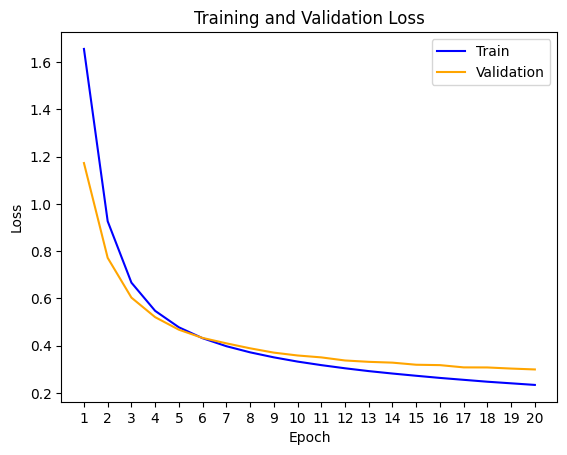

In [ ]:
# visualize loss statistics

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# plot losses
x = list(range(1, n_epoch + 1))
plt.plot(x, train_loss_list, color ="blue", label='Train')
plt.plot(x, valid_loss_list, color="orange", label='Validation')
plt.legend(loc="upper right")
plt.xticks(x)

plt.show()

In [ ]:
# prepare model for evaluation
vision_transformer.eval()

test_loss = 0.0
accuracy = 0

# number of classes
n_class = len(classes)

class_correct = np.zeros(n_class)
class_total = np.zeros(n_class)

# move model back to cpu
vision_transformer = vision_transformer.to('cpu')

# test model
for images, targets in test_loader:

    # get outputs
    outputs = vision_transformer(images)

    # calculate loss
    loss = criterion(outputs, targets)

    # track loss
    test_loss += loss.item()

    # get predictions from probabilities
    preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)

    # get correct predictions
    correct_preds = (preds == targets).type(torch.FloatTensor)

    # calculate and accumulate accuracy
    accuracy += torch.mean(correct_preds).item() * 100

    # calculate test accuracy for each class
    for c in range(n_class):

        targets = targets.to('cpu')

        class_total[c] += (targets == c).sum()
        class_correct[c] += ((correct_preds) * (targets == c)).sum()

# get average accuracy
accuracy = accuracy / len(test_loader)

# get average loss
test_loss = test_loss / len(test_loader)

# output test loss statistics
print('Test Loss: {:.6f}'.format(test_loss))


Test Loss: 0.290069


In [ ]:
class_accuracy = class_correct / class_total

print('Test Accuracy of Classes')
print()

for c in range(n_class):
    print('{}\t: {}% \t ({}/{})'.format(classes[c],
                                int(class_accuracy[c] * 100), int(class_correct[c]), int(class_total[c])) )

print()
print('Test Accuracy of Dataset: \t {}% \t ({}/{})'.format(int(accuracy),
                                                           int(np.sum(class_correct)), int(np.sum(class_total)) ))

Test Accuracy of Classes

airplane	: 91% 	 (94/103)
automobile	: 96% 	 (86/89)
bird	: 82% 	 (82/100)
cat	: 84% 	 (87/103)
deer	: 92% 	 (83/90)
dog	: 89% 	 (77/86)
frog	: 94% 	 (106/112)
horse	: 89% 	 (91/102)
ship	: 95% 	 (101/106)
truck	: 92% 	 (101/109)

Test Accuracy of Dataset: 	 90% 	 (908/1000)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
**Key, Value and Query**

The key/value/query concept is analogous to retrieval systems. For example, when we search for videos on Youtube, the search engine will map our query (text in the search bar) against a set of keys (video title, description, etc.) associated with candidate videos in their database, then present us the best matched videos (values). The dot product can be considered as defining some similarity between the text in search bar (query) and titles in the database (key).

---
**Vision Transformer Success**

>Our Vision Transformer (ViT) attains excellent results when pre-trained at sufficient scale and transferred to tasks with fewer datapoints. When pre-trained on the public ImageNet-21k dataset or the in-house JFT-300M dataset, ViT approaches or beats state of the art on multiple image recognition benchmarks. In particular, the best model reaches the accuracy of 88.55% on ImageNet, 90.72% on ImageNet-ReaL, 94.55% on CIFAR-100, and 77.63% on the VTAB suite of 19 tasks. <br><sub>1 Introduction<sub>


**Vision Transformer Weakness**

>Transformers lack some of the inductive biases inherent to CNNs, such as translation equivariance and locality, and therefore do not generalize well when trained on insufficient amounts of data. <br><sub>1 Introduction<sub>

>**Inductive bias**: We note that Vision Transformer has much less image-specific inductive bias than CNNs. In CNNs, locality, two-dimensional neighborhood structure, and translation equivariance are baked into each layer throughout the whole model. In ViT, only MLP layers are local and translationally equivariant, while the self-attention layers are global. The two-dimensional neighborhood structure is used very sparingly: in the beginning of the model by cutting the image into patches and at fine-tuning time for adjusting the position embeddings for images of different resolution. Other than that, the position embeddings at initialization time carry no information
about the 2D positions of the patches and all spatial relations between the patches have to be learned from scratch. <br><sub>3.1 Vision Transformer (ViT)<sub>

---

**Final Notes**

The implementation here is a very basic representation of how Vision Transformers work. The code structure here is to preserve the simplicity of the code so that to be easier to follow. There are a lot of improvements that can be made in the implementation and calculations can be further optimized.

---

### Resources

1.  An Image is Worth 16x16 Words: Transformers For Image Recognition At Scale Paper - https://arxiv.org/pdf/2010.11929.pdf
2. Illustrated Transformer Blog Post - https://jalammar.github.io/illustrated-transformer/
3. Attention is All You Need Paper - https://arxiv.org/pdf/1706.03762.pdf
4. What exactly are keys, queries, and values in attention mechanisms? - https://stats.stackexchange.com/questions/421935/what-exactly-are-keys-queries-and-values-in-attention-mechanisms

In [ ]:
# in the following, please report 5 random CIFAR-10 images, and the predicted classses of these 5 images
# change the epoch number to 20 ---> [n_epoch = 10] to [n_epoch = 20]
# Hint: check the following code scripts to figure out how to report these 5 images

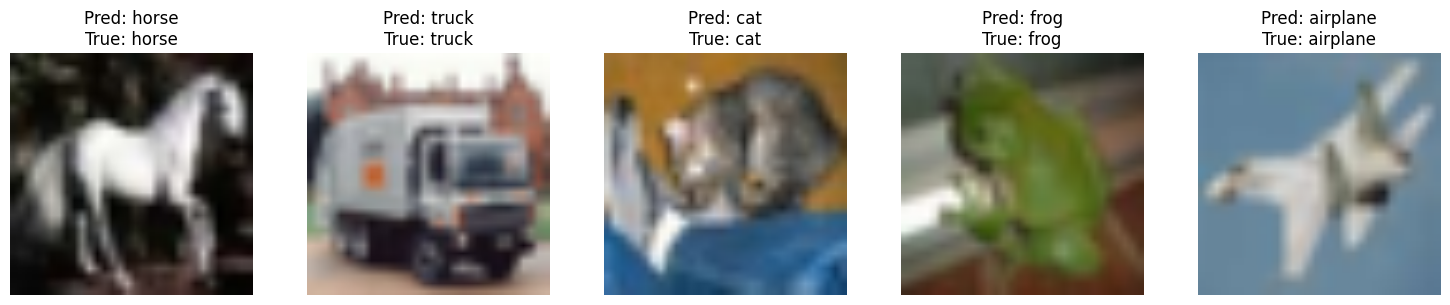

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure model is in evaluation mode
vision_transformer.eval()

# Move model to GPU if available
device = 'cuda' if train_on_gpu else 'cpu'
vision_transformer.to(device)

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Select 5 random indices from the batch
indices = np.random.choice(len(images), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes = axes.flatten()

# Move images to GPU if available for prediction
with torch.no_grad():
    outputs = vision_transformer(images.to(device))
    _, preds = torch.max(outputs, 1)

for i, idx in enumerate(indices):
    # Un-normalize and format image for matplotlib
    img = images[idx].numpy()
    img = np.transpose(img, (1, 2, 0))

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {classes[preds[idx]]}\nTrue: {classes[labels[idx]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import urllib.request
url='https://drive.google.com/uc?id=16XCkJxokwmsYwlMS06LMVf05BCaJjGH6'
url2='https://drive.google.com/uc?export=download&id=1HXGUvSIOoAO46EYVa_PGl2Gn5orvZ6Wc'
urllib.request.urlretrieve(url, 'foo.jpg')

urllib.request.urlretrieve(url2, 'bar.jpg')

os.listdir()

['.config', 'data', 'car.png', 'drive', 'foo.jpg', 'bar.jpg', 'sample_data']

<class 'numpy.ndarray'>
(310, 275, 3)


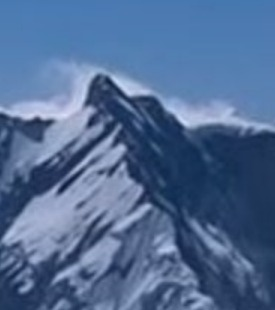

In [ ]:
import cv2
img = cv2.imread('foo.jpg')

print( type(img) )
print( img.shape )

from google.colab.patches import cv2_imshow
cv2_imshow(img)


<class 'numpy.ndarray'>
(106, 83, 3)


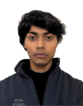

In [ ]:
import cv2
img = cv2.imread('bar.jpg')

print( type(img) )
print( img.shape )

from google.colab.patches import cv2_imshow
cv2_imshow(img)

<class 'numpy.ndarray'>
(64, 64, 3)


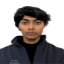

In [ ]:
img1 = cv2.resize(img, (64,64) )

print( type(img1) )
print( img1.shape )

cv2_imshow(img1)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 63,  49,  44],
        [ 65,  52,  50],
        [ 63,  52,  50],
        ...,
        [ 44,  39,  37],
        [ 47,  42,  41],
        [ 42,  37,  36]],

       [[ 58,  46,  42],
        [ 61,  50,  47],
        [ 62,  51,  48],
        ...,
        [ 48,  41,  38],
        [ 45,  36,  34],
        [ 47,  36,  34]],

       [[ 58,  50,  46],
        [ 68,  57,  52],
        [ 67,  56,  52],
        ...,
        [ 51,  45,  44],
        [ 49,  42,  41],
        [ 46,  39,  38]]], dtype=uint8)
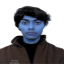

In [ ]:
img1

In [ ]:
# https://github.com/s-chh/PyTorch-Vision-Transformer-ViT-MNIST/blob/main/README.md#vision-transformer-mnist

The following codes were originally come from the [link](https://github.com/s-chh/PyTorch-Vision-Transformer-ViT-MNIST/blob/main/README.md#vision-transformer-mnist)

In [ ]:
# data_loader.py
import torch
from torchvision import datasets
from torchvision import transforms
import os


def get_loader(args):
    if args.dset == 'mnist':
        tr_transform = transforms.Compose([transforms.RandomCrop(args.img_size, padding=2),
                                            transforms.ToTensor(),
                                            transforms.Normalize([0.5], [0.5])])
        train = datasets.MNIST(os.path.join(args.data_path, args.dset), train=True, download=True, transform=tr_transform)

        te_transform = transforms.Compose([transforms.Resize([args.img_size, args.img_size]), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
        test = datasets.MNIST(os.path.join(args.data_path, args.dset), train=False, download=True, transform=te_transform)

    elif args.dset == 'fmnist':
        tr_transform = transforms.Compose([transforms.RandomCrop(args.img_size, padding=2),
                                            transforms.ToTensor(),
                                            transforms.Normalize([0.5], [0.5])])
        train = datasets.FashionMNIST(os.path.join(args.data_path, args.dset), train=True, download=True, transform=tr_transform)

        te_transform = transforms.Compose([transforms.Resize([args.img_size, args.img_size]), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
        test = datasets.FashionMNIST(os.path.join(args.data_path, args.dset), train=False, download=True, transform=te_transform)

    else:
        print("Unknown dataset")
        exit(0)

    train_loader = torch.utils.data.DataLoader(dataset=train,
                                                 batch_size=args.batch_size,
                                                 shuffle=True,
                                                 num_workers=args.num_workers,
                                                 drop_last=True)

    test_loader = torch.utils.data.DataLoader(dataset=test,
                                                batch_size=args.batch_size * 2,
                                                shuffle=False,
                                                num_workers=args.num_workers,
                                                drop_last=False)

    return train_loader, test_loader

In [ ]:
# model.py
import torch
import torch.nn as nn

# B -> Batch Size
# C -> Number of Input Channels
# IH -> Image Height
# IW -> Image Width
# P -> Patch Size
# E -> Embedding Dimension
# S -> Sequence Length = IH/P * IW/P
# Q -> Query Sequence length
# K -> Key Sequence length
# V -> Value Sequence length (same as Key length)
# H -> Number of heads
# HE -> Head Embedding Dimension = E/H


class EmbedLayer(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.args = args
        self.conv1 = nn.Conv2d(args.n_channels, args.embed_dim, kernel_size=args.patch_size, stride=args.patch_size)  # Pixel Encoding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, args.embed_dim), requires_grad=True)  # Cls Token
        self.pos_embedding = nn.Parameter(torch.zeros(1, (args.img_size // args.patch_size) ** 2 + 1, args.embed_dim), requires_grad=True)  # Positional Embedding

    def forward(self, x):
        x = self.conv1(x)  # B C IH IW -> B E IH/P IW/P (Embedding the patches)
        x = x.reshape([x.shape[0], self.args.embed_dim, -1])  # B E IH/P IW/P -> B E S (Flattening the patches)
        x = x.transpose(1, 2)  # B E S -> B S E
        x = torch.cat((torch.repeat_interleave(self.cls_token, x.shape[0], 0), x), dim=1)  # Adding classification token at the start of every sequence
        x = x + self.pos_embedding  # Adding positional embedding
        return x


class SelfAttention(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.n_attention_heads = args.n_attention_heads
        self.embed_dim = args.embed_dim
        self.head_embed_dim = self.embed_dim // self.n_attention_heads

        self.queries = nn.Linear(self.embed_dim, self.head_embed_dim * self.n_attention_heads, bias=True)
        self.keys = nn.Linear(self.embed_dim, self.head_embed_dim * self.n_attention_heads, bias=True)
        self.values = nn.Linear(self.embed_dim, self.head_embed_dim * self.n_attention_heads, bias=True)

    def forward(self, x):
        m, s, e = x.shape

        xq = self.queries(x).reshape(m, s, self.n_attention_heads, self.head_embed_dim)  # B, Q, E -> B, Q, H, HE
        xq = xq.transpose(1, 2)  # B, Q, H, HE -> B, H, Q, HE
        xk = self.keys(x).reshape(m, s, self.n_attention_heads, self.head_embed_dim)  # B, K, E -> B, K, H, HE
        xk = xk.transpose(1, 2)  # B, K, H, HE -> B, H, K, HE
        xv = self.values(x).reshape(m, s, self.n_attention_heads, self.head_embed_dim)  # B, V, E -> B, V, H, HE
        xv = xv.transpose(1, 2)  # B, V, H, HE -> B, H, V, HE

        xq = xq.reshape([-1, s, self.head_embed_dim])  # B, H, Q, HE -> (BH), Q, HE
        xk = xk.reshape([-1, s, self.head_embed_dim])  # B, H, K, HE -> (BH), K, HE
        xv = xv.reshape([-1, s, self.head_embed_dim])  # B, H, V, HE -> (BH), V, HE

        xk = xk.transpose(1, 2)  # (BH), K, HE -> (BH), HE, K
        x_attention = xq.bmm(xk)  # (BH), Q, HE  .  (BH), HE, K -> (BH), Q, K
        x_attention = torch.softmax(x_attention, dim=-1)

        x = x_attention.bmm(xv)  # (BH), Q, K . (BH), V, HE -> (BH), Q, HE
        x = x.reshape([-1, self.n_attention_heads, s, self.head_embed_dim])  # (BH), Q, HE -> B, H, Q, HE
        x = x.transpose(1, 2)  # B, H, Q, HE -> B, Q, H, HE
        x = x.reshape(m, s, e)  # B, Q, H, HE -> B, Q, E
        return x


class Encoder(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.attention = SelfAttention(args)
        self.fc1 = nn.Linear(args.embed_dim, args.embed_dim * args.forward_mul)
        self.activation = nn.GELU()
        self.fc2 = nn.Linear(args.embed_dim * args.forward_mul, args.embed_dim)
        self.norm1 = nn.LayerNorm(args.embed_dim)
        self.norm2 = nn.LayerNorm(args.embed_dim)

    def forward(self, x):
        x = x + self.attention(self.norm1(x)) # Skip connections
        x = x + self.fc2(self.activation(self.fc1(self.norm2(x))))  # Skip connections
        return x


class Classifier(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.fc1 = nn.Linear(args.embed_dim, args.embed_dim)
        self.activation = nn.Tanh()
        self.fc2 = nn.Linear(args.embed_dim, args.n_classes)

    def forward(self, x):
        x = x[:, 0, :]  # Get CLS token
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x


class VisionTransformer(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.embedding = EmbedLayer(args)
        self.encoder = nn.Sequential(*[Encoder(args) for _ in range(args.n_layers)], nn.LayerNorm(args.embed_dim))
        self.norm = nn.LayerNorm(args.embed_dim) # Final normalization layer after the last block
        self.classifier = Classifier(args)

    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        x = self.norm(x)
        x = self.classifier(x)
        return x

In [ ]:
#solver.py

import torch
import torch.nn as nn
import os
from torch import optim
# from model import VisionTransformer
from sklearn.metrics import confusion_matrix, accuracy_score
# from data_loader import get_loader

class Solver(object):
    def __init__(self, args):
        self.args = args

        self.train_loader, self.test_loader = get_loader(args)

        self.model = VisionTransformer(args).cuda()
        self.ce = nn.CrossEntropyLoss()

        print('--------Network--------')
        print(self.model)

        if args.load_model:
            print("Using pretrained model")
            self.model.load_state_dict(torch.load(os.path.join(self.args.model_path, 'Transformer.pt')))

    def test_dataset(self, db='test'):
        self.model.eval()

        actual = []
        pred = []

        if db.lower() == 'train':
            loader = self.train_loader
        else:
            loader = self.test_loader

        for (imgs, labels) in loader:
            imgs = imgs.cuda()

            with torch.no_grad():
                class_out = self.model(imgs)
            _, predicted = torch.max(class_out.data, 1)

            actual += labels.tolist()
            pred += predicted.tolist()

        acc = accuracy_score(y_true=actual, y_pred=pred) * 100
        cm = confusion_matrix(y_true=actual, y_pred=pred, labels=range(self.args.n_classes))

        return acc, cm

    def test(self):
        train_acc, cm = self.test_dataset('train')
        print("Tr Acc: %.2f" % train_acc)
        print(cm)

        test_acc, cm = self.test_dataset('test')
        print("Te Acc: %.2f" % test_acc)
        print(cm)

        return train_acc, test_acc

    def train(self):
        iter_per_epoch = len(self.train_loader)

        optimizer = optim.AdamW(self.model.parameters(), self.args.lr, weight_decay=1e-3)
        cos_decay = optim.lr_scheduler.CosineAnnealingLR(optimizer, self.args.epochs)

        for epoch in range(self.args.epochs):

            self.model.train()

            for i, (imgs, labels) in enumerate(self.train_loader):

                imgs, labels = imgs.cuda(), labels.cuda()

                logits = self.model(imgs)
                clf_loss = self.ce(logits, labels)

                optimizer.zero_grad()
                clf_loss.backward()
                optimizer.step()

                if i % 50 == 0 or i == (iter_per_epoch - 1):
                    print('Ep: %d/%d, it: %d/%d, err: %.4f' % (epoch + 1, self.args.epochs, i + 1, iter_per_epoch, clf_loss))

            test_acc, cm = self.test_dataset('test')
            print("Test acc: %0.2f" % test_acc)
            print(cm, "\n")

            cos_decay.step()

In [ ]:
import shlex
import argparse
#argString = '--dset mnist'
#parser = argparse.ArgumentParser()
#args = parser.parse_args(shlex.split(argString))
import easydict
from easydict import EasyDict

args = easydict.EasyDict({
    'epochs':20,
    'dset': 'mnist',
    'model_path': './model',
    'img_size':28,
    'data_path':'./data/',
    'batch_size': 128,
    'n_classes': 10,
    'num_workers': 4,
    'lr' : 5e-4,
    'log_step' : 5,
    'patch_size': 4,
    'n_channels' : 1,
    'embed_dim' : 96,
    'n_attention_heads' : 4,
    'forward_mul' : 2,
    'n_layers' : 6,
    'load_model' : False,
})

if 1 :
    #args.model_path='./model'
    os.makedirs(args.model_path, exist_ok=True)

    solver = Solver(args)
    solver.train()
    solver.test()

--------Network--------
VisionTransformer(
  (embedding): EmbedLayer(
    (conv1): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True)
      )
      (fc1): Linear(in_features=96, out_features=192, bias=True)
      (activation): GELU(approximate='none')
      (fc2): Linear(in_features=192, out_features=96, bias=True)
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 1/20, it: 1/468, err: 2.2969
Ep: 1/20, it: 51/468, err: 1.6018
Ep: 1/20, it: 101/468, err: 1.2597
Ep: 1/20, it: 151/468, err: 1.2304
Ep: 1/20, it: 201/468, err: 1.0953
Ep: 1/20, it: 251/468, err: 0.8568
Ep: 1/20, it: 301/468, err: 0.9541
Ep: 1/20, it: 351/468, err: 0.7017
Ep: 1/20, it: 401/468, err: 0.5251
Ep: 1/20, it: 451/468, err: 0.6100
Ep: 1/20, it: 468/468, err: 0.7454
Test acc: 85.50
[[ 825    0   12    1    0   30   45    3   57    7]
 [   0 1113    0    4    0    6    3    8    1    0]
 [   6    0  831   63    0   58    7   17   46    4]
 [   0    1   29  795    0  166    0    4   11    4]
 [   1   29    3    0  731    1   87    6   13  111]
 [   0    1    5   54    0  802    2    1   25    2]
 [  21   12    4    1    3   29  851    0   36    1]
 [   0   19   16   28    2    9    0  924    2   28]
 [   4    1   18   28    0   45   10    1  859    8]
 [   5   10    3   12    6   26   12   43   73  819]] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 2/20, it: 1/468, err: 0.5564
Ep: 2/20, it: 51/468, err: 0.6961
Ep: 2/20, it: 101/468, err: 0.3200
Ep: 2/20, it: 151/468, err: 0.4490
Ep: 2/20, it: 201/468, err: 0.4294
Ep: 2/20, it: 251/468, err: 0.4508
Ep: 2/20, it: 301/468, err: 0.3771
Ep: 2/20, it: 351/468, err: 0.2938
Ep: 2/20, it: 401/468, err: 0.3011
Ep: 2/20, it: 451/468, err: 0.2853
Ep: 2/20, it: 468/468, err: 0.2865
Test acc: 93.68
[[ 957    0    4    1    1    4    5    0    6    2]
 [   0 1120    3    2    1    2    3    2    1    1]
 [  11    1  974   14    2    3    2   11   10    4]
 [   0    2   10  966    0   20    0    4    3    5]
 [   1    4    0    0  920    0    7    3    2   45]
 [   4    0    2   65    1  798    3    3   12    4]
 [  13    5    2    0   12   13  906    0    7    0]
 [   4   17   29   14    4    1    0  918    1   40]
 [  18    0   11   23    1    9   22    0  876   14]
 [   7    6    0   11   19    9    1    9   14  933]] 



...

Ep: 20/20, it: 1/468, err: 0.0043
Ep: 20/20, it: 51/468, err: 0.0175
Ep: 20/20, it: 101/468, err: 0.0057
Ep: 20/20, it: 151/468, err: 0.0135
Ep: 20/20, it: 201/468, err: 0.0733
Ep: 20/20, it: 251/468, err: 0.0229
Ep: 20/20, it: 301/468, err: 0.0133
Ep: 20/20, it: 351/468, err: 0.0059
Ep: 20/20, it: 401/468, err: 0.0146
Ep: 20/20, it: 451/468, err: 0.0638
Ep: 20/20, it: 468/468, err: 0.0350
Test acc: 99.37
[[ 976    0    0    1    0    1    1    1    0    0]
 [   0 1132    2    0    0    0    0    1    0    0]
 [   0    0 1026    0    0    0    0    5    1    0]
 [   0    0    1 1006    0    2    0    0    1    0]
 [   0    0    0    0  975    0    1    1    0    5]
 [   1    0    0    1    0  887    1    1    1    0]
 [   3    3    0    0    1    1  949    0    1    0]
 [   0    3    3    0    1    0    0 1020    0    1]
 [   0    0    3    2    0    0    0    0  968    1]
 [   1    1    0    0    4    2    0    2    1  998]] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Tr Acc: 99.25
[[5893    1    0    2    1    3    8    0    5    2]
 [   0 6707    8    0    2    0    1   11    0    2]
 [   3    9 5905    4    1    1    1   14    8    1]
 [   0    1   10 6068    0   14    0    9   17    6]
 [   0    4    5    0 5782    1    7    5    2   24]
 [   5    1    3   12    0 5369   14    3    5    4]
 [   7    1    3    0    1    3 5888    0    5    0]
 [   2   13   11    7    7    0    0 6184    6   17]
 [   5    3   11    8    4    7    7    1 5790    7]
 [   4    0    0    6   34    7    0   14   10 5867]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Te Acc: 99.37
[[ 976    0    0    1    0    1    1    1    0    0]
 [   0 1132    2    0    0    0    0    1    0    0]
 [   0    0 1026    0    0    0    0    5    1    0]
 [   0    0    1 1006    0    2    0    0    1    0]
 [   0    0    0    0  975    0    1    1    0    5]
 [   1    0    0    1    0  887    1    1    1    0]
 [   3    3    0    0    1    1  949    0    1    0]
 [   0    3    3    0    1    0    0 1020    0    1]
 [   0    0    3    2    0    0    0    0  968    1]
 [   1    1    0    0    4    2    0    2    1  998]]


## Your Works here

Below is a code segment to assist you in preparing your final report.

You are expected to build upon this code segment and ultimately present your results on two datasets: MNIST and Fashion MNIST (FMNIST).

Your final report grade will be based on developing bug-free models as well as the final accuracy of your program. Please note that your report must include:

- 10 random MNIST images along with their predicted classes.
- 20 random Fashion MNIST images along with their predicted classes.



In [ ]:
# @title
# main.py

import argparse
import datetime
import os
# from solver import Solver
# Run commands:
# python main.py --dset mnist
# python main.py --dset fmnist

# ref link: https://stackoverflow.com/questions/8878478/how-can-i-use-pythons-argparse-with-a-predefined-argument-string
import shlex
argString = '--dset mnist'
# Removed the initial parser setup as it conflicts with the one in __main__
# parser = argparse.ArgumentParser()
# args = parser.parse_args(shlex.split(argString))


def main(args):
    os.makedirs(args.model_path, exist_ok=True)

    solver = Solver(args)
    solver.train()
    solver.test()


def print_args(args):
    for k in dict(sorted(vars(args).items())).items():
        print(k)
    print()


if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Transformer')
    parser.add_argument('--epochs', type=int, default=200)
    parser.add_argument('--batch_size', type=int, default=128)
    parser.add_argument('--n_classes', type=int, default=10)
    parser.add_argument('--num_workers', type=int, default=4)
    parser.add_argument('--lr', type=float, default=5e-4)
    parser.add_argument('--log_step', type=int, default=50)

    parser.add_argument('--dset', type=str, default='mnist', help=['mnist', 'fmnist'])
    parser.add_argument("--img_size", type=int, default=28, help="Img size")
    parser.add_argument("--patch_size", type=int, default=4, help="Patch Size")
    parser.add_argument("--n_channels", type=int, default=1, help="Number of channels")
    parser.add_argument('--data_path', type=str, default='./data/')
    parser.add_argument('--model_path', type=str, default='./model')

    parser.add_argument("--embed_dim", type=int, default=96, help="dimensionality of the latent space")
    parser.add_argument("--n_attention_heads", type=int, default=4, help="number of heads to be used")
    parser.add_argument("--forward_mul", type=int, default=2, help="forward multiplier")
    parser.add_argument("--n_layers", type=int, default=6, help="number of encoder layers")
    parser.add_argument("--load_model", type=bool, default=False, help="Load saved model")

    start_time = datetime.datetime.now()
    print("Started at " + str(start_time.strftime('%Y-%m-%d %H:%M:%S')))

    # Pass the argString explicitly to parse_args to prevent it from trying to parse sys.argv
    args = parser.parse_args(shlex.split(argString))
    args.model_path = os.path.join(args.model_path, args.dset)
    print(args)

    main(args)

    end_time = datetime.datetime.now()
    duration = end_time - start_time
    print("Ended at " + str(end_time.strftime('%Y-%m-%d %H:%M:%S')))
    print("Duration: " + str(duration))

Started at 2026-05-31 05:20:42
Namespace(epochs=200, batch_size=128, n_classes=10, num_workers=4, lr=0.0005, log_step=50, dset='mnist', img_size=28, patch_size=4, n_channels=1, data_path='./data/', model_path='./model/mnist', embed_dim=96, n_attention_heads=4, forward_mul=2, n_layers=6, load_model=False)
--------Network--------
VisionTransformer(
  (embedding): EmbedLayer(
    (conv1): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True)
      )
      (fc1): Linear(in_features=96, out_features=192, bias=True)
      (activation): GELU(approximate='none')
      (fc2): Linear(in_features=192, out_features=96, bias=True)
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 1/200, it: 1/468, err: 2.3477
Ep: 1/200, it: 51/468, err: 1.5352
Ep: 1/200, it: 101/468, err: 1.2976
Ep: 1/200, it: 151/468, err: 1.3106
Ep: 1/200, it: 201/468, err: 1.1927
Ep: 1/200, it: 251/468, err: 1.1261
Ep: 1/200, it: 301/468, err: 0.7613
Ep: 1/200, it: 351/468, err: 0.6736
Ep: 1/200, it: 401/468, err: 0.5635
Ep: 1/200, it: 451/468, err: 0.3773
Ep: 1/200, it: 468/468, err: 0.4606
Test acc: 84.94
[[ 929    0   19    1    1    1    8    1   20    0]
 [   0 1077    7    3    9    0    4   20    6    9]
 [   9    0  928   35    1    1    5   10   37    6]
 [   0    0   49  905    0    9    0    9   35    3]
 [   3    2    2    0  823    0   25   12    8  107]
 [   8    1   63  252    0  455    4    4  100    5]
 [  78    3   12    0   31    6  767    1   58    2]
 [   4    3   28   31    3    1    0  908    4   46]
 [  20    0   60   19    0    2    5    2  853   13]
 [  16    2   13   15   10    1    8   33   62  849]] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 2/200, it: 1/468, err: 0.5060
Ep: 2/200, it: 51/468, err: 0.5273
Ep: 2/200, it: 101/468, err: 0.3262
Ep: 2/200, it: 151/468, err: 0.4924
Ep: 2/200, it: 201/468, err: 0.4289
Ep: 2/200, it: 251/468, err: 0.3824
Ep: 2/200, it: 301/468, err: 0.2601
Ep: 2/200, it: 351/468, err: 0.3255
Ep: 2/200, it: 401/468, err: 0.4085
Ep: 2/200, it: 451/468, err: 0.2401
Ep: 2/200, it: 468/468, err: 0.2449
Test acc: 92.83
[[ 951    0    5    0    7    0   12    1    3    1]
 [   4 1081    6    3    9    3    8   15    3    3]
 [   8    1  995    4    2    1    3    2   14    2]
 [   1    1   30  879    0   45    0   12   35    7]
 [   0    2    0    0  934    0   18    1    3   24]
 [  10    2    6    9    0  809   16    2   36    2]
 [  10    1    2    0   10    3  926    0    6    0]
 [   4    7   33    4    7    0    0  958    2   13]
 [  11    0   11    0    3    5   25    2  904   13]
 [   6    4    3    3   75    5    0   33   34  846]] 



...

Ep: 200/200, it: 1/468, err: 0.0000
Ep: 200/200, it: 51/468, err: 0.0003
Ep: 200/200, it: 101/468, err: 0.0005
Ep: 200/200, it: 151/468, err: 0.0000
Ep: 200/200, it: 201/468, err: 0.0000
Ep: 200/200, it: 251/468, err: 0.0000
Ep: 200/200, it: 301/468, err: 0.0001
Ep: 200/200, it: 351/468, err: 0.0001
Ep: 200/200, it: 401/468, err: 0.0001
Ep: 200/200, it: 451/468, err: 0.0000
Ep: 200/200, it: 468/468, err: 0.0001
Test acc: 99.41
[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1132    1    1    0    0    0    1    0    0]
 [   0    0 1030    0    0    0    0    2    0    0]
 [   0    0    0 1008    0    2    0    0    0    0]
 [   0    0    1    0  972    0    3    0    0    6]
 [   0    0    0    3    0  886    1    2    0    0]
 [   2    2    1    0    0    1  951    0    1    0]
 [   0    3    4    0    2    0    0 1019    0    0]
 [   0    0    1    2    0    1    1    0  968    1]
 [   0    0    0    0    6    2    0    2    2  997]] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Tr Acc: 99.99
[[5912    0    0    0    0    0    0    0    0    0]
 [   0 6730    0    0    0    0    0    1    0    0]
 [   0    0 5949    0    0    0    0    0    0    0]
 [   0    0    0 6122    0    0    0    0    0    1]
 [   0    0    0    0 5834    0    0    0    0    1]
 [   0    0    0    2    0 5413    0    0    0    0]
 [   0    0    0    0    0    0 5906    0    0    0]
 [   0    0    0    0    0    0    0 6256    0    0]
 [   0    0    0    0    0    0    0    0 5839    0]
 [   0    0    0    0    1    0    0    0    0 5937]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Te Acc: 99.41
[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1132    1    1    0    0    0    1    0    0]
 [   0    0 1030    0    0    0    0    2    0    0]
 [   0    0    0 1008    0    2    0    0    0    0]
 [   0    0    1    0  972    0    3    0    0    6]
 [   0    0    0    3    0  886    1    2    0    0]
 [   2    2    1    0    0    1  951    0    1    0]
 [   0    3    4    0    2    0    0 1019    0    0]
 [   0    0    1    2    0    1    1    0  968    1]
 [   0    0    0    0    6    2    0    2    2  997]]
Ended at 2026-05-31 06:54:21
Duration: 1:33:38.591015


In [ ]:
# In the following section, please present your results on both the MNIST and Fashion MNIST datasets.
#
# Please report and display:
# - 10 random MNIST images along with their predicted classes.
# - 20 random Fashion MNIST images along with their predicted classes.


--- Training on MNIST ---
--------Network--------
VisionTransformer(
  (embedding): EmbedLayer(
    (conv1): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True)
      )
      (fc1): Linear(in_features=96, out_features=192, bias=True)
      (activation): GELU(approximate='none')
      (fc2): Linear(in_features=192, out_features=96, bias=True)
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, 

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 1/10, it: 1/468, err: 2.2944
Ep: 1/10, it: 51/468, err: 1.5263
Ep: 1/10, it: 101/468, err: 1.3648
Ep: 1/10, it: 151/468, err: 1.2890
Ep: 1/10, it: 201/468, err: 0.9691
Ep: 1/10, it: 251/468, err: 0.8222
Ep: 1/10, it: 301/468, err: 0.5941
Ep: 1/10, it: 351/468, err: 0.6199
Ep: 1/10, it: 401/468, err: 0.4820
Ep: 1/10, it: 451/468, err: 0.4372
Ep: 1/10, it: 468/468, err: 0.4667
Test acc: 88.86
[[ 922    0    5    0    4   13   20    5    4    7]
 [   0 1114    4    1    0    0    0   16    0    0]
 [  15    3  923   13    2    7    6   23   34    6]
 [   0    1   61  835    0   54    0   37   15    7]
 [   1   19    4    0  873    0   20   20    1   44]
 [   3    6   20   60    2  760   11    3   16   11]
 [  18   17    2    0   23   17  868    0   12    1]
 [   1   12   22    3    2    3    0  970    0   15]
 [  36    4   37   18    8   13   28    2  778   50]
 [  10   11    4    7   36   14    4   74    6  843]] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 2/10, it: 1/468, err: 0.4055
Ep: 2/10, it: 51/468, err: 0.3416
Ep: 2/10, it: 101/468, err: 0.4662
Ep: 2/10, it: 151/468, err: 0.3898
Ep: 2/10, it: 201/468, err: 0.3288
Ep: 2/10, it: 251/468, err: 0.3422
Ep: 2/10, it: 301/468, err: 0.3209
Ep: 2/10, it: 351/468, err: 0.2911
Ep: 2/10, it: 401/468, err: 0.4513
Ep: 2/10, it: 451/468, err: 0.2294
Ep: 2/10, it: 468/468, err: 0.1618
Test acc: 93.75
[[ 961    0    3    0    1    0    8    1    2    4]
 [   3 1118    5    1    0    1    6    0    1    0]
 [  15    1  966    2    5    1   10    7   20    5]
 [   0    0   29  946    0   16    0    4   12    3]
 [   2    3    0    0  942    0   13    1    2   19]
 [   2    0    0   44    3  793   12    4   25    9]
 [   5    3    0    0    2    7  934    0    7    0]
 [   2   29   27    6    7    1    0  940    1   15]
 [  15    0   17    6    2    3   14    1  905   11]
 [  11    7    1   17   50    2    5   16   30  870]] 



...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Tr Acc: 98.08
[[5850    0    5    5    2    6   20    5   14    6]
 [   1 6674   19    7    1    2    5   16    4    2]
 [   8   13 5823   22   11    4    6   35   23    6]
 [   1    3   52 5955    2   38    0   29   31    9]
 [   7   10    7    0 5701    1   14   18    6   68]
 [   7    1    2   36    2 5303   12    4   33    9]
 [  20    3    8    1   10   21 5834    0   13    0]
 [   0   12   27   14   21    4    0 6146    5   24]
 [  15    8   25   18   14   28   19    7 5682   28]
 [  14    2    3   18   41   14    0   40   24 5785]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Te Acc: 98.54
[[ 971    0    3    0    0    0    2    1    3    0]
 [   0 1129    2    0    0    0    1    1    1    1]
 [   3    0 1015    2    3    0    1    4    4    0]
 [   0    0    2  991    0    6    0    6    5    0]
 [   0    0    0    0  963    0    5    0    0   14]
 [   1    0    0    4    0  884    1    2    0    0]
 [   3    3    0    0    2    7  940    0    2    1]
 [   0    3    5    0    2    0    0 1015    2    1]
 [   2    0    4    3    0    1    1    2  959    2]
 [   2    1    0    1    6    3    0    6    3  987]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


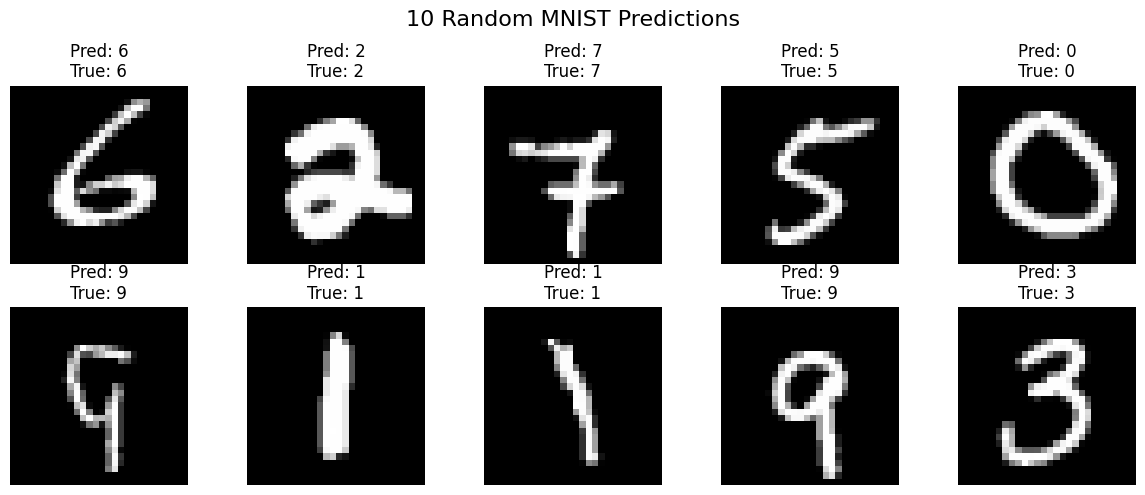

In [ ]:
# Configure args for MNIST
args.dset = 'mnist'
args.n_channels = 1
args.n_classes = 10
args.epochs = 10 # Adjust epochs as needed for your training limits

# Initialize and run solver
print("--- Training on MNIST ---")
solver_mnist = Solver(args)
solver_mnist.train()
solver_mnist.test()

# Fetch data for visualization
solver_mnist.model.eval()
dataiter = iter(solver_mnist.test_loader)
images, labels = next(dataiter)

# Pick 10 random images
indices = np.random.choice(len(images), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

with torch.no_grad():
    outputs = solver_mnist.model(images.cuda())
    _, preds = torch.max(outputs, 1)

for i, idx in enumerate(indices):
    # Remove channel dimension for grayscale and denormalize
    img = images[idx].squeeze().numpy()
    img = img * 0.5 + 0.5

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {preds[idx].item()}\nTrue: {labels[idx].item()}")
    axes[i].axis('off')

plt.suptitle("10 Random MNIST Predictions", fontsize=16)
plt.tight_layout()
plt.show()

#MNIST Predictions


# 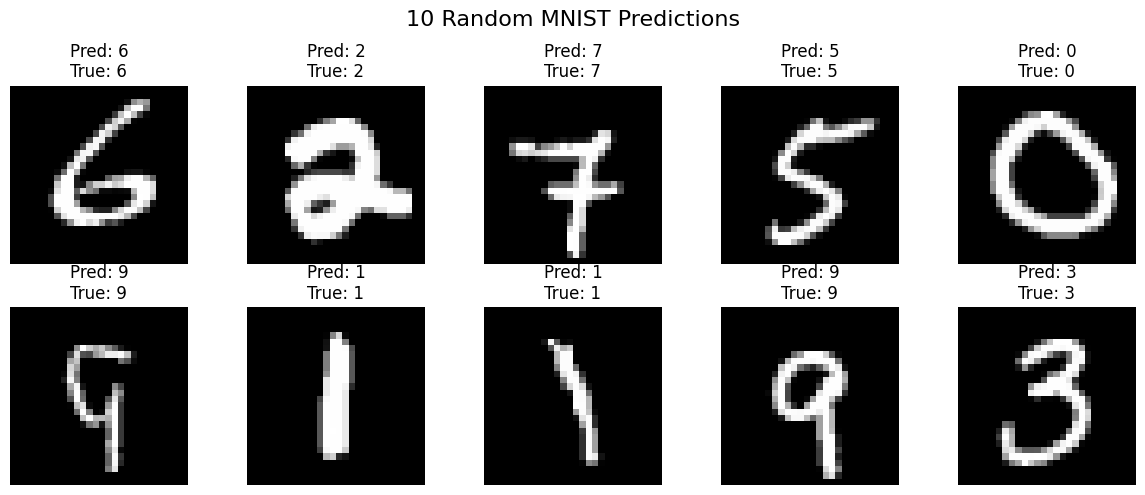

--- Training on Fashion MNIST ---


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.6MB/s]

--------Network--------
VisionTransformer(
  (embedding): EmbedLayer(
    (conv1): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True)
      )
      (fc1): Linear(in_features=96, out_features=192, bias=True)
      (activation): GELU(approximate='none')
      (fc2): Linear(in_features=192, out_features=96, bias=True)
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Encoder(
      (attention): SelfAttention(
        (queries): Linear(in_features=96, out_features=96, bias=True)
        (keys): Linear(in_features=96, out_features=96, bias=True)
        (values): Linear(in_features=96, out_features=96, bias=True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep: 1/10, it: 1/468, err: 2.3468
Ep: 1/10, it: 51/468, err: 1.4634
Ep: 1/10, it: 101/468, err: 1.0053
Ep: 1/10, it: 151/468, err: 0.8701
Ep: 1/10, it: 201/468, err: 0.9464
Ep: 1/10, it: 251/468, err: 0.8453
Ep: 1/10, it: 301/468, err: 0.7172
Ep: 1/10, it: 351/468, err: 0.7423
Ep: 1/10, it: 401/468, err: 0.6592
Ep: 1/10, it: 451/468, err: 0.7379
Ep: 1/10, it: 468/468, err: 0.6610
Test acc: 73.20
[[736   1  31 149  13   4  36   0  30   0]
 [  1 880   4  99   8   0   2   0   6   0]
 [ 17  32 780  15  88   0  42   0  26   0]
 [ 39   9  17 869  37   3  18   0   7   1]
 [ 13   9 420  92 403   1  33   0  29   0]
 [  0   0   0   0   0 807   0 149   6  38]
 [216   7 473 110  85   0  61   0  48   0]
 [  0   0   0   0   0  21   0 935   1  43]
 [  5   0   9  13   2   9   0  11 948   3]
 [  0   0   0   1   0  12   0  83   3 901]] 



...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Tr Acc: 86.91
[[5050   10   99  215   36    0  531    0   47    1]
 [   7 5821    7  124   16    0   14    0    2    0]
 [  60   11 4771   62  662    3  397    0   21    0]
 [ 170   70   44 5312  259    1  129    0    6    3]
 [  18    7  581  225 4664    0  482    0   16    0]
 [   0    2    0    3    1 5698    1  206   16   65]
 [ 993   11  617  178  523    1 3614    0   53    0]
 [   0    0    0    0    0  110    0 5665    8  200]
 [  25    3   48   16   32   17   45    4 5797    6]
 [   0    1    0    6    0   60    1  246    6 5672]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Te Acc: 86.92
[[843   0  14  40   5   1  85   0  12   0]
 [  1 970   2  20   5   0   1   0   1   0]
 [ 18   0 798  14 106   0  63   0   1   0]
 [ 15  11  12 890  34   0  38   0   0   0]
 [  1   1 103  37 779   0  78   0   1   0]
 [  0   0   0   0   0 957   0  33   2   8]
 [173   1  96  35  92   0 585   0  18   0]
 [  0   0   0   0   0  18   0 957   0  25]
 [  0   1  13   6   4   5   6   3 961   1]
 [  0   0   0   1   1   6   0  40   0 952]]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


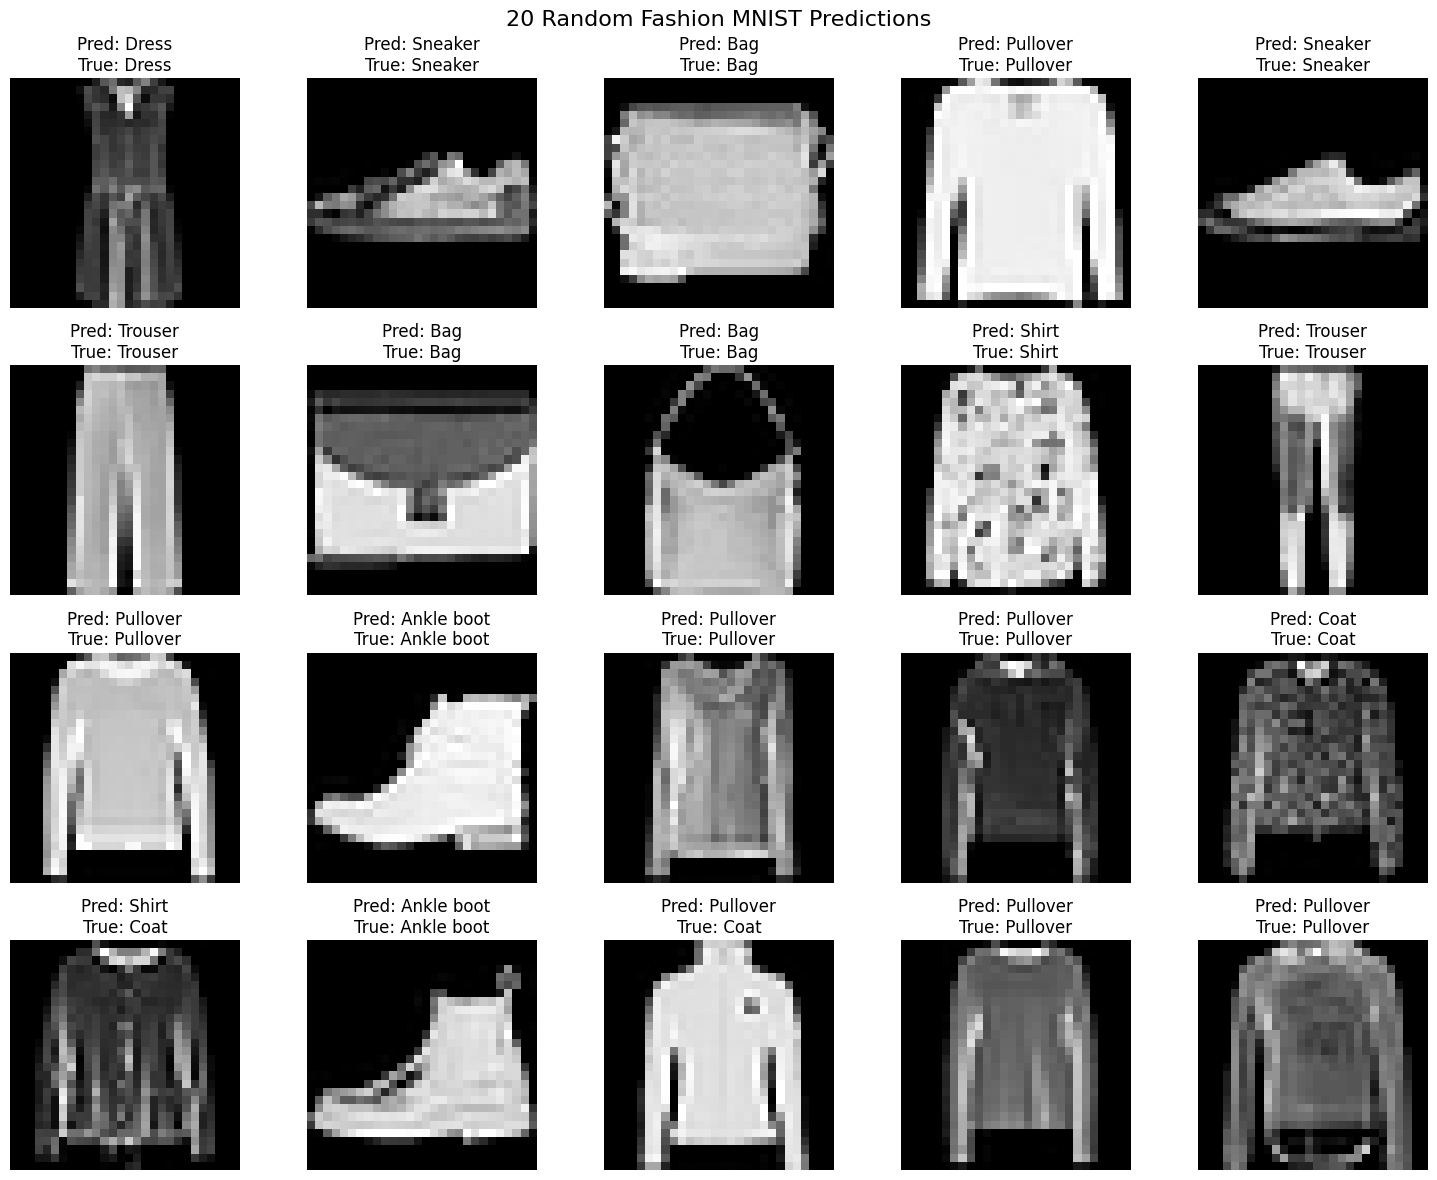

In [ ]:
# Configure args for Fashion MNIST
args.dset = 'fmnist'
args.n_channels = 1
args.n_classes = 10

# Initialize and run solver
print("--- Training on Fashion MNIST ---")
solver_fmnist = Solver(args)
solver_fmnist.train()
solver_fmnist.test()

# FMNIST label mapping for readable plotting
fmnist_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Fetch data for visualization
solver_fmnist.model.eval()
dataiter = iter(solver_fmnist.test_loader)
images, labels = next(dataiter)

# Pick 20 random images
indices = np.random.choice(len(images), 20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

with torch.no_grad():
    outputs = solver_fmnist.model(images.cuda())
    _, preds = torch.max(outputs, 1)

for i, idx in enumerate(indices):
    # Remove channel dimension for grayscale and denormalize
    img = images[idx].squeeze().numpy()
    img = img * 0.5 + 0.5

    pred_label = fmnist_classes[preds[idx].item()]
    true_label = fmnist_classes[labels[idx].item()]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}")
    axes[i].axis('off')

plt.suptitle("20 Random Fashion MNIST Predictions", fontsize=16)
plt.tight_layout()
plt.show()

#FMNIST Predictions

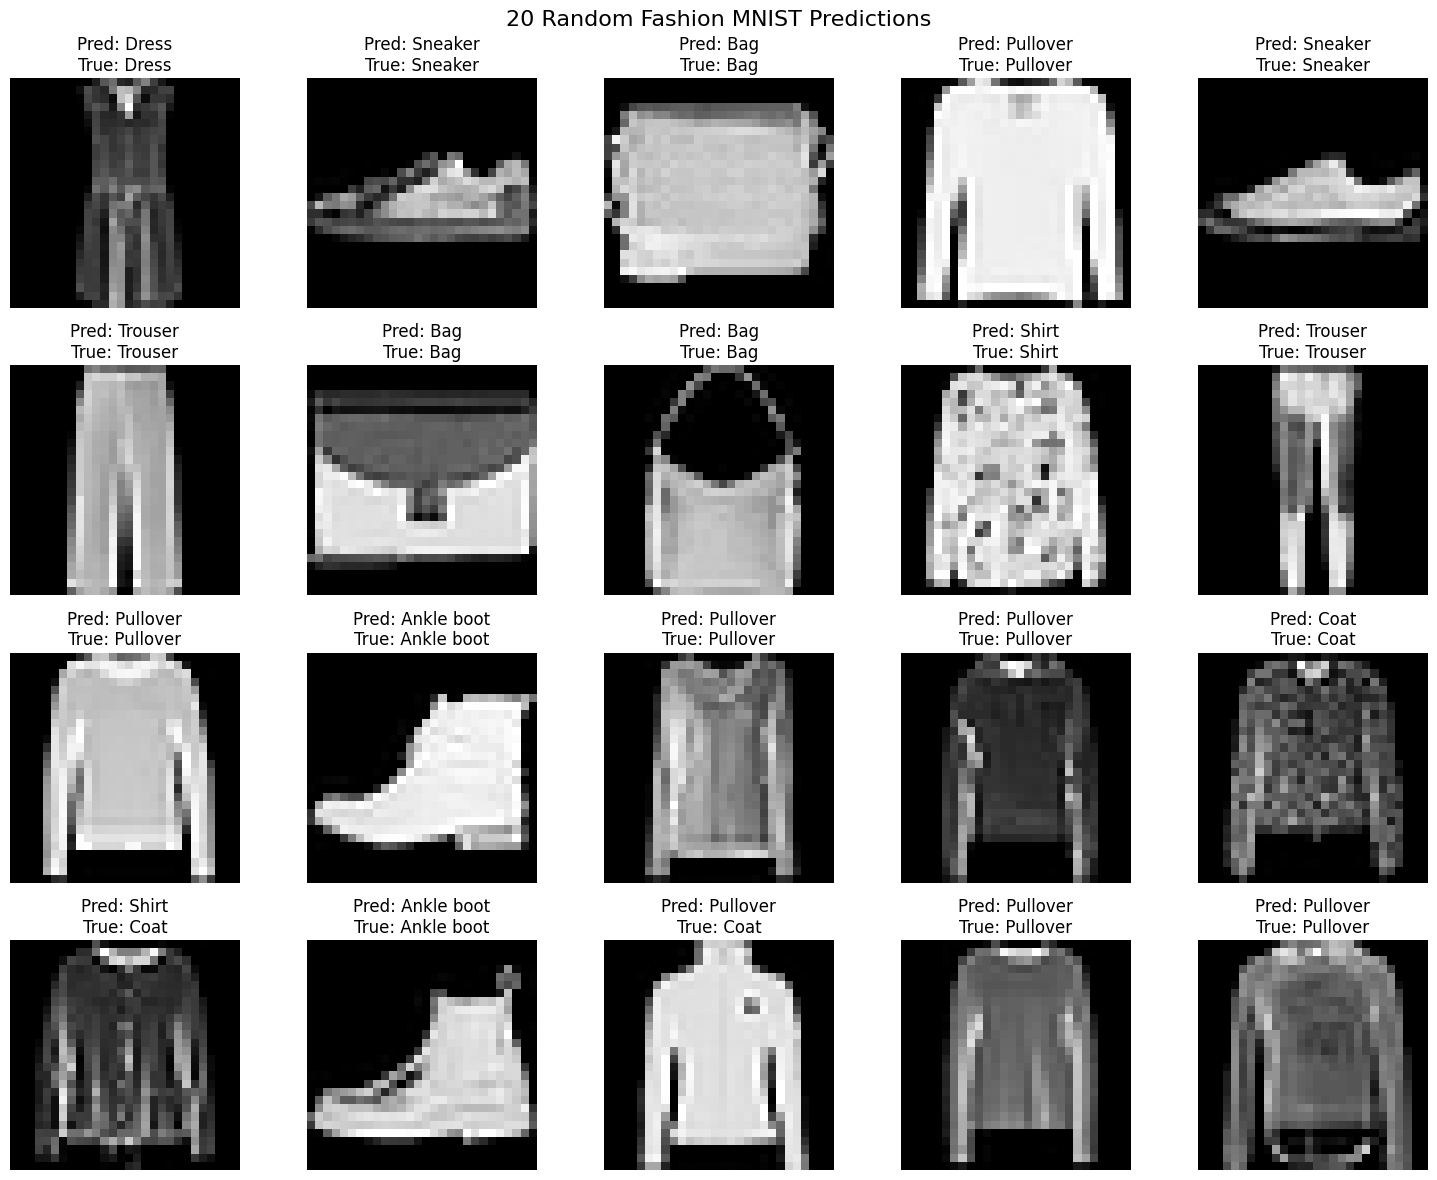